# Zephyr Boards per SOC Vendor

Breakdown of supported boards by SOC vendor, with a split between:
- **Vendor's boards**: boards made by the SOC vendor (e.g. ST's Nucleo boards)
- **Community boards**: boards from other companies using that vendor's chips (e.g. Adafruit Feather with STM32)

*Requires: `pip install pandas matplotlib`*

## Setup

In [1]:
import sys
from pathlib import Path

# Notebook lives in scripts/; Zephyr base is parent
ZEPHYR_BASE = Path.cwd().parent
if not (ZEPHYR_BASE / 'boards').is_dir():
    ZEPHYR_BASE = Path.cwd()  # maybe cwd is already zephyr root
assert (ZEPHYR_BASE / 'boards').is_dir(), f'Not a Zephyr base. Run from zephyr/ or zephyr/scripts/'

# Add scripts dir for imports
sys.path.insert(0, str(ZEPHYR_BASE / 'scripts'))

In [2]:
import argparse
import list_boards
import list_hardware
import zephyr_module

def get_args(zephyr_base: Path):
    module_settings = {
        'arch_root': [zephyr_base],
        'board_root': [zephyr_base],
        'soc_root': [zephyr_base],
    }
    for module in zephyr_module.parse_modules(zephyr_base):
        for key in module_settings:
            root = module.meta.get('build', {}).get('settings', {}).get(key)
            if root is not None:
                module_settings[key].append(Path(module.project) / root)
    return argparse.Namespace(
        arch_roots=module_settings['arch_root'],
        board_roots=module_settings['board_root'],
        soc_roots=module_settings['soc_root'],
        board=None, board_dir=[],
    )

root_args = get_args(ZEPHYR_BASE)
systems = list_hardware.find_v2_systems(root_args)
boards = list_boards.find_v2_boards(root_args)

## Load & Analyze

In [3]:
# Merge vendors that are effectively the same (e.g. Atmel acquired by Microchip)
VENDOR_MERGE = {'atmel': 'microchip'}

def normalize_vendor(v: str) -> str:
    return VENDOR_MERGE.get(v, v)

def get_vendor_from_soc_path(soc_folder: str) -> str:
    path = Path(soc_folder)
    try:
        idx = path.parts.index('soc')
        if idx + 1 < len(path.parts):
            return normalize_vendor(path.parts[idx + 1].lower())
    except (ValueError, IndexError):
        pass
    return '(unknown)'

def get_board_vendor(board) -> str:
    raw = None
    if board.vendor:
        raw = board.vendor.lower()
    else:
        try:
            raw = board.dir.parent.name.lower()
        except Exception:
            pass
    return normalize_vendor(raw) if raw else '(unknown)'

# Build: soc_vendor -> { 'vendor_boards': set(names), 'community_boards': set(names) }
vendor_data = {}
for board in boards.values():
    board_vendor = get_board_vendor(board)
    for soc in board.socs:
        try:
            hw_soc = systems.get_soc(soc.name)
        except SystemExit:
            continue
        soc_vendor = get_vendor_from_soc_path(hw_soc.folder[0])
        if soc_vendor not in vendor_data:
            vendor_data[soc_vendor] = {'vendor_boards': set(), 'community_boards': set()}
        bucket = vendor_data[soc_vendor]
        if board_vendor == soc_vendor:
            bucket['vendor_boards'].add(board.name)
        else:
            bucket['community_boards'].add(board.name)

# Convert to counts for display
vendor_counts = {}
for v, data in vendor_data.items():
    all_boards = data['vendor_boards'] | data['community_boards']
    vendor_counts[v] = {
        'vendor': len(data['vendor_boards']),
        'community': len(data['community_boards']),
        'total': len(all_boards),
    }

# Sort by total descending
sorted_vendors = sorted(vendor_counts.keys(), key=lambda x: -vendor_counts[x]['total'])

## Summary Table

In [4]:
import pandas as pd

rows = []
for v in sorted_vendors:
    c = vendor_counts[v]
    rows.append({'SOC Vendor': v, 'Vendor boards': c['vendor'], 'Community boards': c['community'], 'Total': c['total']})
df = pd.DataFrame(rows)
df

,SOC Vendor,Vendor boards,Community boards,Total
0,st,129,83,212
1,nordic,23,104,127
2,nxp,83,25,108
3,espressif,13,64,77
4,renesas,57,5,62
5,silabs,48,12,60
6,microchip,31,18,49
7,raspberrypi,3,39,42
8,intel,21,5,26
9,ti,16,9,25


## Charts

In [5]:
import matplotlib.pyplot as plt
import numpy as np

try:
    plt.style.use('seaborn-v0_8-whitegrid')
except OSError:
    try:
        plt.style.use('ggplot')
    except OSError:
        pass
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 12

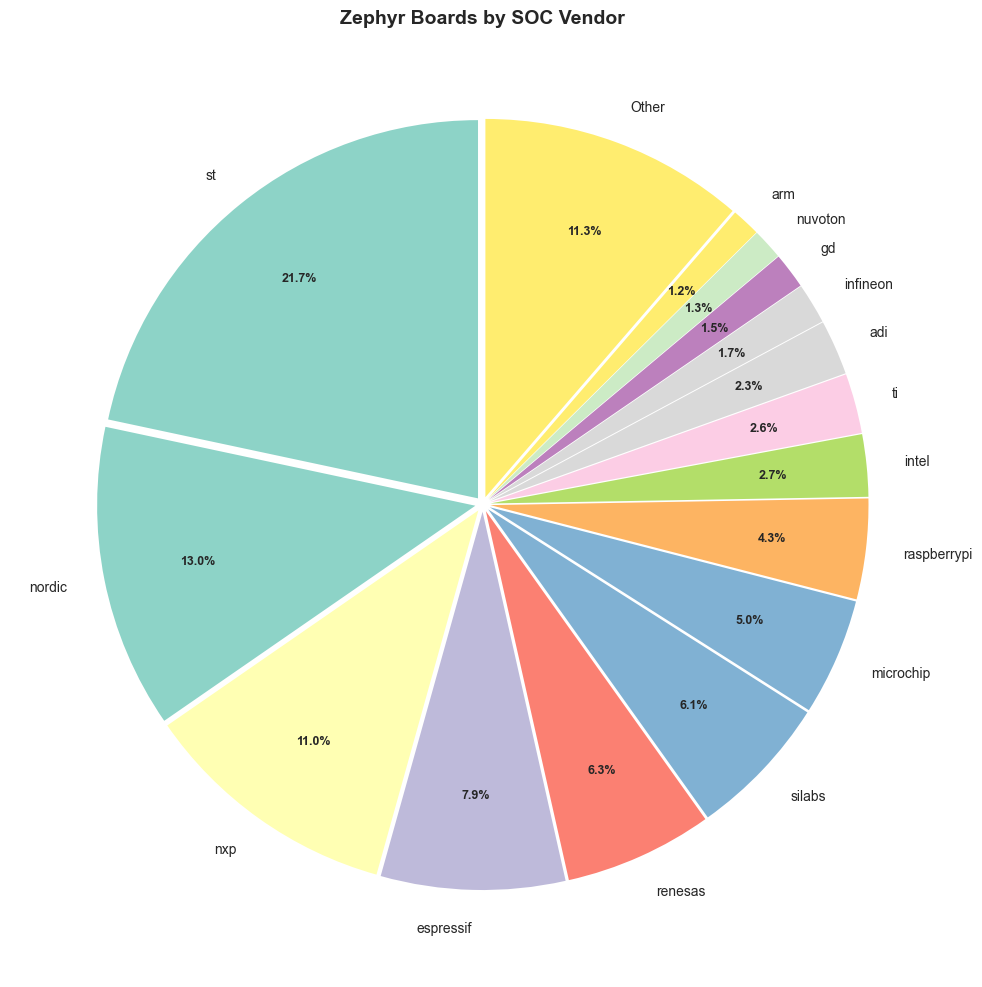

In [6]:
# Pie chart: overall distribution by SOC vendor (top 15)
top_n = 15
top_vendors = sorted_vendors[:top_n]
top_totals = [vendor_counts[v]['total'] for v in top_vendors]
other_total = sum(vendor_counts[v]['total'] for v in sorted_vendors[top_n:])

labels = list(top_vendors) + (['Other'] if other_total > 0 else [])
sizes = top_totals + ([other_total] if other_total > 0 else [])
colors = plt.cm.Set3(np.linspace(0, 1, len(labels)))
explode = [0.02] * len(labels)

fig, ax = plt.subplots(figsize=(10, 10))
wedges, texts, autotexts = ax.pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors,
    explode=explode, startangle=90, pctdistance=0.75, textprops={'fontsize': 13})
plt.setp(autotexts, size=14, weight='bold')
ax.set_title('Zephyr Boards by SOC Vendor', fontsize=18, fontweight='bold')
plt.setp(texts, size=13)
plt.tight_layout()
plt.show()

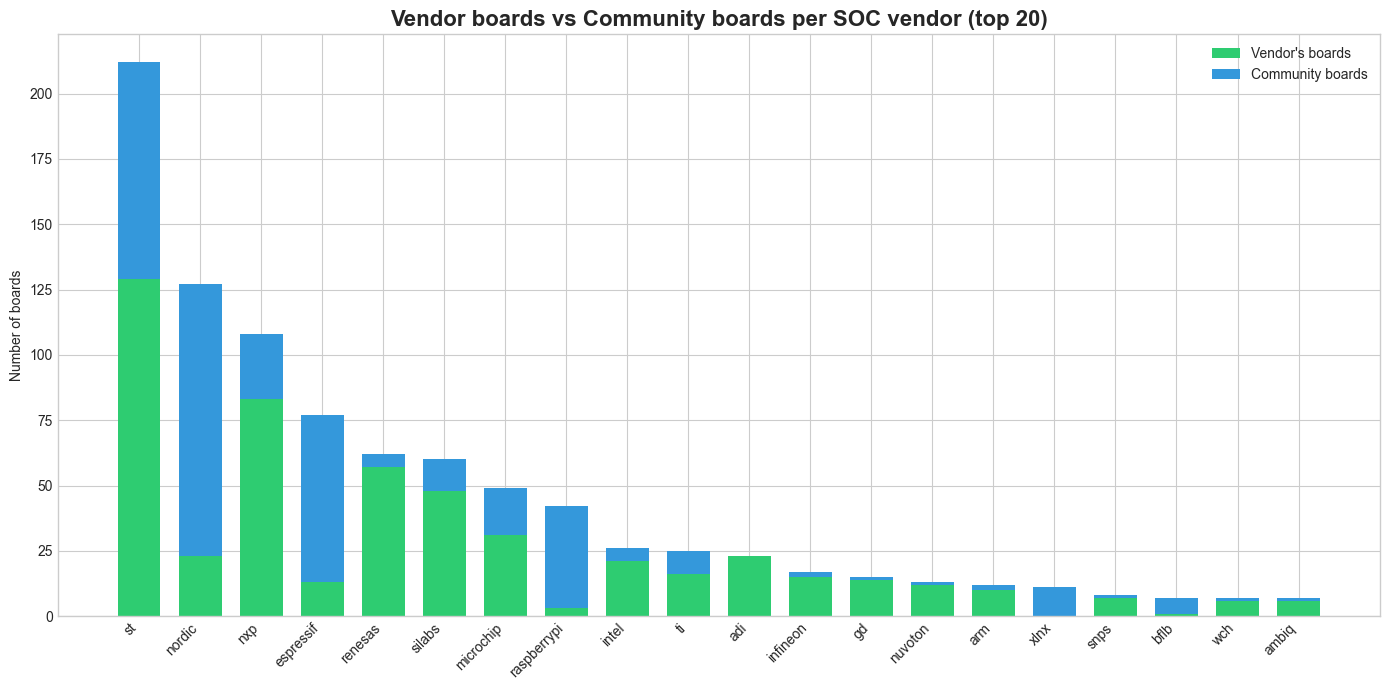

In [7]:
# Stacked bar: Vendor boards vs Community boards per SOC vendor (top 20)
n_bars = 20
plot_vendors = sorted_vendors[:n_bars]
vendor_n = [vendor_counts[v]['vendor'] for v in plot_vendors]
community_n = [vendor_counts[v]['community'] for v in plot_vendors]

x = np.arange(len(plot_vendors))
width = 0.7

fig, ax = plt.subplots(figsize=(14, 7))
bars1 = ax.bar(x, vendor_n, width, label="Vendor's boards", color='#2ecc71')
bars2 = ax.bar(x, community_n, width, bottom=vendor_n, label='Community boards', color='#3498db')

ax.set_ylabel('Number of boards', fontsize=14)
ax.set_title("Vendor boards vs Community boards per SOC vendor (top 20)", fontsize=18, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(plot_vendors, rotation=45, ha='right', fontsize=12)
ax.legend(fontsize=13)
plt.tight_layout()
plt.show()

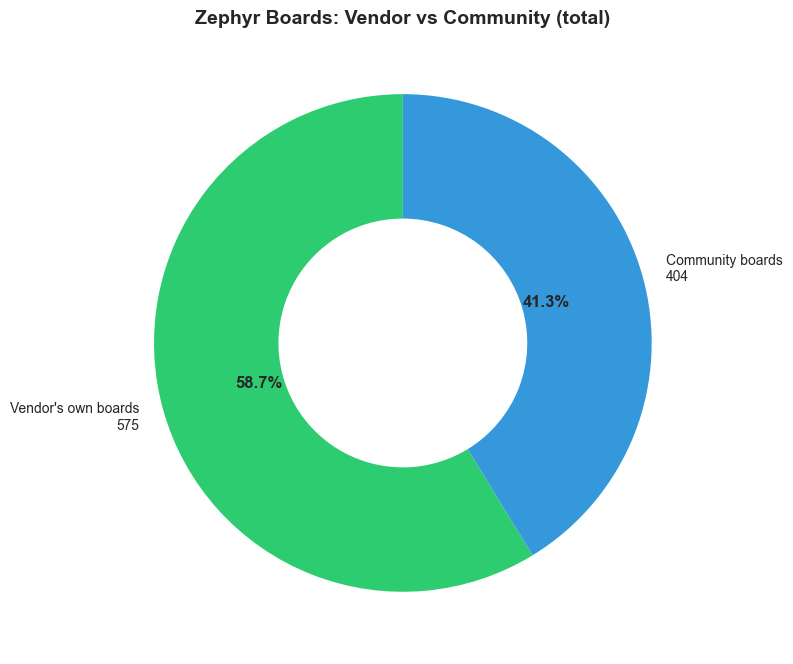

In [8]:
# Donut chart: Vendor vs Community across all boards
total_vendor = sum(vendor_counts[v]['vendor'] for v in vendor_counts)
total_community = sum(vendor_counts[v]['community'] for v in vendor_counts)
total_boards = len(boards)

fig, ax = plt.subplots(figsize=(8, 8))
sizes = [total_vendor, total_community]
labels = [f"Vendor's own boards\n{total_vendor}", f"Community boards\n{total_community}"]
colors = ['#2ecc71', '#3498db']
wedges, texts, autotexts = ax.pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors,
    startangle=90, wedgeprops=dict(width=0.5), textprops={'fontsize': 14})
plt.setp(autotexts, size=16, weight='bold')
ax.set_title('Zephyr Boards: Vendor vs Community (total)', fontsize=18, fontweight='bold')
plt.setp(texts, size=14)
plt.tight_layout()
plt.show()